# Decision Tree

## Learning objective

This notebook covers the **CART-style decision tree** for classification, a
model that splits the feature space into rectangular regions with a sequence of
simple yes/no questions. You should finish able to:

- explain recursive binary splitting and how a tree is grown,
- define **Gini impurity** and use **information gain** to choose splits,
- implement a `DecisionTreeClassifierScratch` from scratch with `fit` and
  `predict`, and
- discuss interpretability, axis-aligned splits, the role of `max_depth`, and
  why unconstrained trees overfit.

## The mathematical idea

A decision tree partitions the data by repeatedly asking questions of the form
“is feature $j$ less than or equal to a threshold $t$?” Each such question is a
**binary split** that sends points either left or right. Growing the tree by
choosing one split at a time and then recursing on each side is called
**recursive binary splitting**.

To decide *which* split is best we need a measure of how mixed the labels are in
a node. For a node containing class proportions $p_1, \dots, p_C$, the **Gini
impurity** is

$$
G = 1 - \sum_{c=1}^{C} p_c^2 .
$$

A pure node (all one class) has $G = 0$; a node split evenly between two classes
has $G = 0.5$. A candidate split divides a parent node into left and right
children with $n_L$ and $n_R$ points. Its quality is the **information gain**,
the drop in impurity from parent to the size-weighted children:

$$
\text{gain} = G_{\text{parent}}
  - \frac{n_L}{n}\,G_{\text{left}}
  - \frac{n_R}{n}\,G_{\text{right}} .
$$

At each node we search over every feature and every candidate threshold and keep
the split with the **largest gain**. We stop splitting when a node is pure, when
it is too small to split, or when a maximum depth is reached.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## A reproducible dataset

We generate a small two-dimensional, two-class dataset as two Gaussian blobs
placed so the classes are mostly separable but overlap a little. Because the
data are two-dimensional we can later draw the decision regions the tree learns.

In [2]:
n_per_class = 100

X_neg = rng.normal(loc=[-1.0, -1.0], scale=1.1, size=(n_per_class, 2))
X_pos = rng.normal(loc=[1.8, 1.8], scale=1.1, size=(n_per_class, 2))

X = np.vstack([X_neg, X_pos])
y = np.concatenate([np.zeros(n_per_class), np.ones(n_per_class)]).astype(int)

print('Feature matrix shape:', X.shape)
print('Label distribution:', {0: int((y == 0).sum()), 1: int((y == 1).sum())})

Feature matrix shape: (200, 2)
Label distribution: {0: 100, 1: 100}


## Train/test split

We shuffle with a fixed seed and hold out 30% of the data for testing, so the
accuracies below reflect performance on points the tree has never seen.

In [3]:
n_samples = X.shape[0]
n_test = int(0.3 * n_samples)

perm = rng.permutation(n_samples)
test_idx, train_idx = perm[:n_test], perm[n_test:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print('Train size:', X_train.shape[0])
print('Test size :', X_test.shape[0])

Train size: 140
Test size : 60


## Decision tree from scratch

The implementation has three pieces:

- **`_gini`** computes the Gini impurity of a set of labels.
- **`_best_split`** searches every feature and every candidate threshold (the
  midpoints between sorted unique values) and returns the split with the highest
  information gain.
- **`_build`** is the recursive tree-building routine. It stops and creates a
  **leaf** (storing the majority label) when the node is pure, too small, at the
  depth limit, or when no split improves impurity. Otherwise it stores the
  chosen feature/threshold and recurses on the left and right subsets.

Internal nodes are stored as dictionaries with `feature`, `threshold`, `left`,
and `right`; leaves are dictionaries with a `leaf` label. `predict` walks a
single point down the tree until it reaches a leaf.

In [4]:
class DecisionTreeClassifierScratch:
    """A from-scratch CART-style classification tree using Gini impurity."""

    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

    @staticmethod
    def _gini(y):
        # 1 - sum of squared class proportions.
        counts = np.bincount(y)
        proportions = counts / counts.sum()
        return 1.0 - np.sum(proportions ** 2)

    def _best_split(self, X, y):
        n_samples, n_features = X.shape
        parent_gini = self._gini(y)
        best_gain = 0.0
        best = None
        for feature in range(n_features):
            values = np.unique(X[:, feature])
            # Candidate thresholds are midpoints between adjacent unique values.
            thresholds = (values[:-1] + values[1:]) / 2.0
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask
                n_left, n_right = left_mask.sum(), right_mask.sum()
                if n_left == 0 or n_right == 0:
                    continue
                gain = (parent_gini
                        - (n_left / n_samples) * self._gini(y[left_mask])
                        - (n_right / n_samples) * self._gini(y[right_mask]))
                if gain > best_gain:
                    best_gain = gain
                    best = (feature, threshold, left_mask, right_mask)
        return best_gain, best

    def _build(self, X, y, depth):
        # Stop and make a leaf when the node cannot or should not be split.
        depth_reached = self.max_depth is not None and depth >= self.max_depth
        if (len(np.unique(y)) == 1
                or len(y) < self.min_samples_split
                or depth_reached):
            return {'leaf': np.bincount(y).argmax()}

        gain, best = self._best_split(X, y)
        if best is None or gain == 0.0:
            return {'leaf': np.bincount(y).argmax()}

        feature, threshold, left_mask, right_mask = best
        left = self._build(X[left_mask], y[left_mask], depth + 1)
        right = self._build(X[right_mask], y[right_mask], depth + 1)
        return {'feature': feature, 'threshold': threshold,
                'left': left, 'right': right}

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        self.tree_ = self._build(X, y, depth=0)
        return self

    def _predict_one(self, x, node):
        while 'leaf' not in node:
            if x[node['feature']] <= node['threshold']:
                node = node['left']
            else:
                node = node['right']
        return node['leaf']

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(x, self.tree_) for x in X])

## Train and report accuracy

We fit a depth-limited tree and report both train and test accuracy. Comparing
the two numbers is the simplest way to watch for overfitting: a large gap
(high train accuracy, lower test accuracy) signals that the tree has memorized
the training data.

In [5]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


tree = DecisionTreeClassifierScratch(max_depth=3).fit(X_train, y_train)
train_acc = accuracy(y_train, tree.predict(X_train))
test_acc = accuracy(y_test, tree.predict(X_test))

print('Train accuracy:', round(train_acc, 4))
print('Test accuracy :', round(test_acc, 4))

Train accuracy: 0.9929
Test accuracy : 0.9667


## Effect of tree depth

To see overfitting directly, we grow trees of increasing depth and track train
and test accuracy. Shallow trees may underfit; very deep trees push train
accuracy toward 1.0 while test accuracy stops improving (or drops), because the
extra splits fit noise rather than signal.

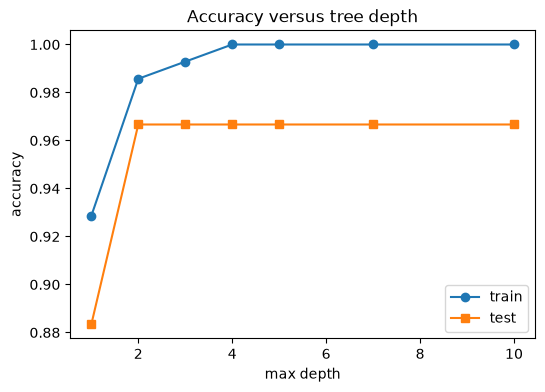

In [6]:
depths = [1, 2, 3, 4, 5, 7, 10]
train_scores, test_scores = [], []
for d in depths:
    t = DecisionTreeClassifierScratch(max_depth=d).fit(X_train, y_train)
    train_scores.append(accuracy(y_train, t.predict(X_train)))
    test_scores.append(accuracy(y_test, t.predict(X_test)))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(depths, train_scores, marker='o', label='train')
ax.plot(depths, test_scores, marker='s', label='test')
ax.set_xlabel('max depth')
ax.set_ylabel('accuracy')
ax.set_title('Accuracy versus tree depth')
ax.legend()
plt.show()

## Decision regions

We shade the predicted class across a dense grid for the depth-limited tree and
overlay the training points colored by their true label. Notice that the
boundaries are **axis-aligned**: every edge is a horizontal or vertical line,
because each split compares a single feature against a threshold.

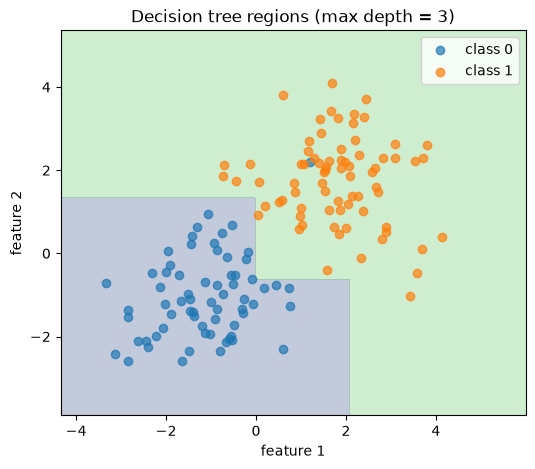

In [7]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.column_stack([xx.ravel(), yy.ravel()])
zz = tree.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, zz, alpha=0.3, levels=1)
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
           label='class 0', alpha=0.7)
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
           label='class 1', alpha=0.7)
ax.set_xlabel('feature 1')
ax.set_ylabel('feature 2')
ax.set_title('Decision tree regions (max depth = 3)')
ax.legend()
plt.show()

## Interpretation

The accuracy-versus-depth plot shows the classic overfitting pattern: train
accuracy keeps climbing as depth grows, while test accuracy levels off once the
tree is deep enough to capture the real structure. The decision-region plot
makes the model's inductive bias concrete — the regions are unions of
axis-aligned rectangles.

### Interpretability, axis-aligned splits, overfitting, and regularization

- **Interpretability.** A trained tree is a short list of human-readable rules
  (“if feature 1 ≤ t and feature 2 > s then class 1”). This transparency is one
  of the main reasons trees are popular in teaching and in settings that demand
  explanations.
- **Axis-aligned splits.** Because each split thresholds a single feature, the
  boundaries are always horizontal or vertical. A boundary that is naturally
  diagonal must be approximated by a staircase of many small splits, which is
  inefficient.
- **Overfitting risk.** Left unconstrained, a tree can keep splitting until
  every leaf is pure, perfectly fitting the training data — including its noise.
  Such a tree generalizes poorly, which is the gap we saw at large depths.
- **Pruning and regularization.** We limit complexity here with `max_depth` and
  `min_samples_split`. Other common controls are a minimum number of samples per
  leaf, a minimum impurity decrease required to split, and **post-pruning**,
  which grows a full tree and then collapses branches that do not help on held-
  out data.

## Limitations and next steps

A single tree is **high-variance**: small changes in the training data can
produce a very different tree. Natural next steps are to tune the depth with
cross-validation, and — most importantly — to average many trees together with
**bagging** and **random forests**, which is the subject of the next notebook.